## 1. Data Loading

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [33]:
abs_train = pd.read_csv("/ddn_scratch/k5zhao/data/classifier_training/abs_train.csv")
abs_val   = pd.read_csv("/ddn_scratch/k5zhao/data/classifier_training/abs_val.csv")
abs_test  = pd.read_csv("/ddn_scratch/k5zhao/data/classifier_training/abs_test.csv")

rel_train = pd.read_csv("/ddn_scratch/k5zhao/data/classifier_training/rel_train.csv")
rel_val   = pd.read_csv("/ddn_scratch/k5zhao/data/classifier_training/rel_val.csv")
rel_test  = pd.read_csv("/ddn_scratch/k5zhao/data/classifier_training/rel_test.csv")

/tmp/ipykernel_47589/191890810.py:1: DtypeWarning: Columns (1274) have mixed types. Specify dtype option on import or set low_memory=False.
  abs_train = pd.read_csv("/ddn_scratch/k5zhao/data/classifier_training/abs_train.csv")
/tmp/ipykernel_47589/191890810.py:5: DtypeWarning: Columns (1274) have mixed types. Specify dtype option on import or set low_memory=False.
  rel_train = pd.read_csv("/ddn_scratch/k5zhao/data/classifier_training/rel_train.csv")


## 2. Basic Cleaning

### Separate features (X) and target (y)

In [34]:
def split_X_y(df, target="bmi"):
    feature_cols = [c for c in df.columns if c.startswith("G")]
    X = df[feature_cols]
    y = df[target]
    return X, y

In [35]:
X_abs_train, y_abs_train = split_X_y(abs_train)
X_abs_val,   y_abs_val   = split_X_y(abs_val)
X_abs_test,  y_abs_test  = split_X_y(abs_test)

X_rel_train, y_rel_train = split_X_y(rel_train)
X_rel_val,   y_rel_val   = split_X_y(rel_val)
X_rel_test,  y_rel_test  = split_X_y(rel_test)

## 3. Exploratory Data Analysis (EDA)

### Basic quality checks

In [36]:
print(X_abs_train.isna().sum().sum()) 
print((X_abs_train < 0).sum().sum())
print(X_abs_train.shape)

print(X_rel_train.isna().sum().sum()) 
print((X_rel_train < 0).sum().sum())
print(X_rel_train.shape)

0
0
(1910, 1148)
0
0
(1910, 1148)


### Distribution Diagnostics

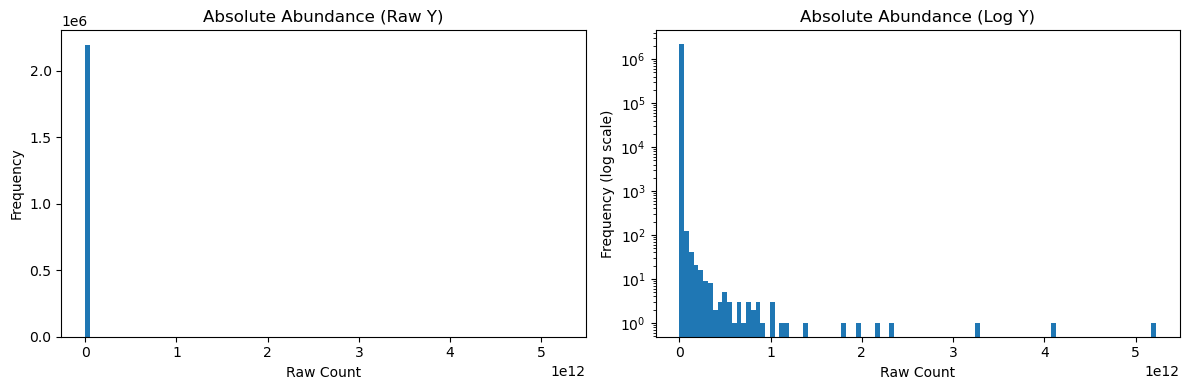

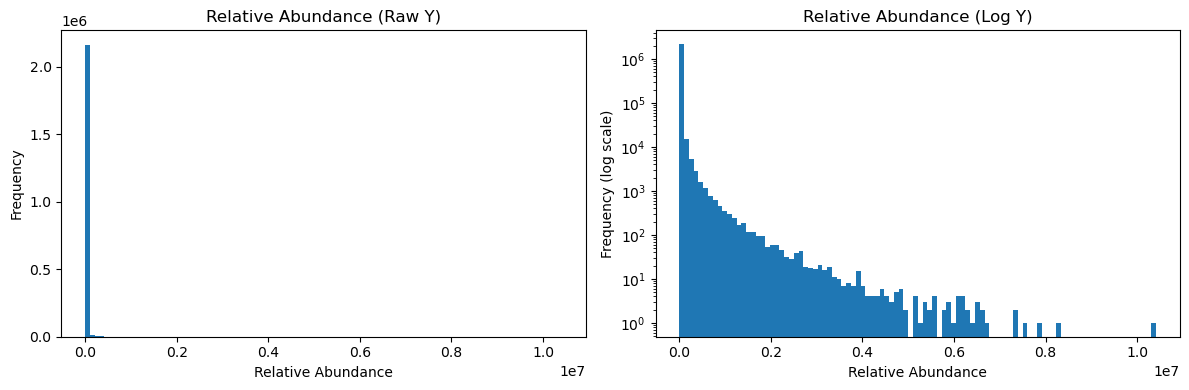

In [37]:
# Flatten feature values
abs_vals = abs_train[[c for c in abs_train.columns if c.startswith("G")]].values.flatten()
rel_vals = rel_train[[c for c in rel_train.columns if c.startswith("G")]].values.flatten()

# ABSOLUTE ABUNDANCE
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Raw Y-scale
axes[0].hist(abs_vals, bins=100)
axes[0].set_title("Absolute Abundance (Raw Y)")
axes[0].set_xlabel("Raw Count")
axes[0].set_ylabel("Frequency")

# Log Y-scale
axes[1].hist(abs_vals, bins=100)
axes[1].set_yscale("log")
axes[1].set_title("Absolute Abundance (Log Y)")
axes[1].set_xlabel("Raw Count")
axes[1].set_ylabel("Frequency (log scale)")

plt.tight_layout()
plt.show()


# RELATIVE ABUNDANCE
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Raw Y-scale
axes[0].hist(rel_vals, bins=100)
axes[0].set_title("Relative Abundance (Raw Y)")
axes[0].set_xlabel("Relative Abundance")
axes[0].set_ylabel("Frequency")

# Log Y-scale
axes[1].hist(rel_vals, bins=100)
axes[1].set_yscale("log")
axes[1].set_title("Relative Abundance (Log Y)")
axes[1].set_xlabel("Relative Abundance")
axes[1].set_ylabel("Frequency (log scale)")

plt.tight_layout()
plt.show()

In [38]:
print("ABS max:", X_abs_train.max().max())
print("REL max:", X_rel_train.max().max())

print("REL row sum stats:")
print(X_rel_train.sum(axis=1).describe())

ABS max: 5225222801820.961
REL max: 10415540.0
REL row sum stats:
count    1.910000e+03
mean     8.951591e+06
std      3.526548e+06
min      4.218000e+03
25%      6.612083e+06
50%      8.520516e+06
75%      1.085802e+07
max      3.149474e+07
dtype: float64


## Log transform counts

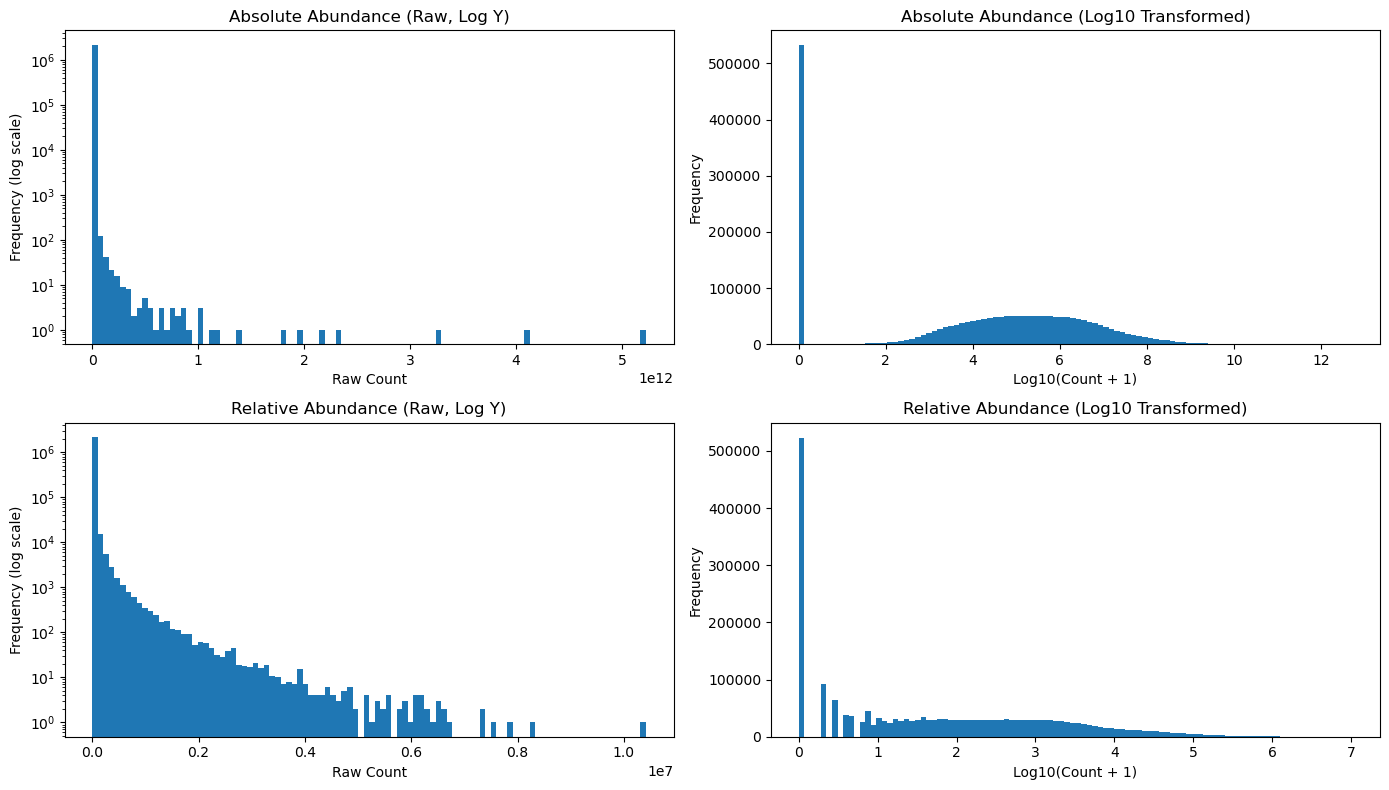

In [39]:
# Flatten values
abs_raw = abs_train[abs_feature_cols].values.flatten()
rel_raw = rel_train[rel_feature_cols].values.flatten()

# Log transform
abs_log = np.log10(abs_raw + 1)
rel_log = np.log10(rel_raw + 1)

# Plot 2x2 Diagnostic Panel
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# ---- Absolute Raw ----
axes[0, 0].hist(abs_raw, bins=100)
axes[0, 0].set_yscale("log")
axes[0, 0].set_title("Absolute Abundance (Raw, Log Y)")
axes[0, 0].set_xlabel("Raw Count")
axes[0, 0].set_ylabel("Frequency (log scale)")

# ---- Absolute Log ----
axes[0, 1].hist(abs_log, bins=100)
axes[0, 1].set_title("Absolute Abundance (Log10 Transformed)")
axes[0, 1].set_xlabel("Log10(Count + 1)")
axes[0, 1].set_ylabel("Frequency")

# ---- Relative Raw ----
axes[1, 0].hist(rel_raw, bins=100)
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("Relative Abundance (Raw, Log Y)")
axes[1, 0].set_xlabel("Raw Count")
axes[1, 0].set_ylabel("Frequency (log scale)")

# ---- Relative Log ----
axes[1, 1].hist(rel_log, bins=100)
axes[1, 1].set_title("Relative Abundance (Log10 Transformed)")
axes[1, 1].set_xlabel("Log10(Count + 1)")
axes[1, 1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 4. Plate Bias Diagnostic

In [40]:
print(abs_plate_df["sample_plate"].value_counts())

sample_plate
NPH_15288_Plate_38            52
NPH_15288_Plate_10            51
NPH_15288_Plate_31            45
NPH_15288_Plate_12            44
NPH_15288_Plate_3             44
                              ..
NPH_15288_Plate_10_diluted     6
NPH_15288_Plate_9_diluted      5
NPH_15288_Plate_38_diluted     5
NPH_15288_Plate_20_diluted     4
NPH_15288_Plate_8_diluted      2
Name: count, Length: 73, dtype: int64


ABS X shape: (3114, 1148) | #plates: 38
REL X shape: (3114, 1148) | #plates: 38
ABS baseline (majority class accuracy): 0.027938342967244702
REL baseline (majority class accuracy): 0.027938342967244702

ABS CV accuracy: 0.33396799017305534
ABS CV balanced accuracy: 0.33059690137863507

REL CV accuracy: 0.19010750801277915
REL CV balanced accuracy: 0.18923575908096033


<Figure size 1200x1000 with 0 Axes>

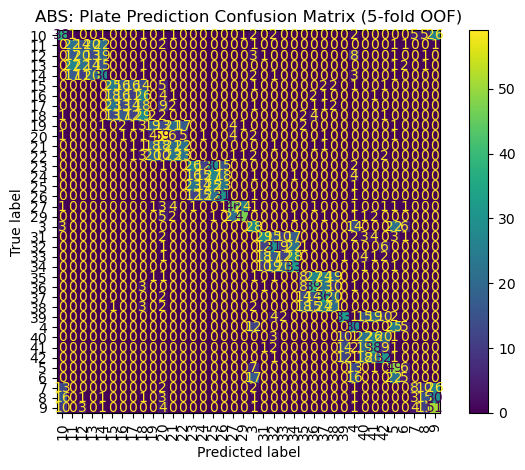

/home/zhw074/miniforge3/envs/qiime2-moshpit-2025.7/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


<Figure size 1200x1000 with 0 Axes>

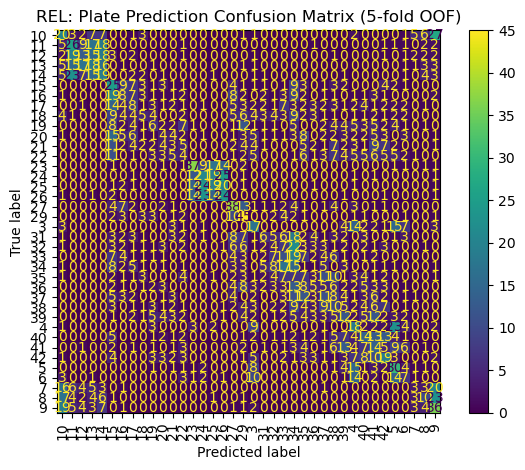

In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, balanced_accuracy_score
)

# 0. Helper: build X, y for plate prediction
def build_plate_xy(df, plate_col="sample_plate"):
    df = df.copy()

    # keep valid plate
    df = df.dropna(subset=[plate_col])

    # merge "_diluted" with base plate by extracting the plate number
    # e.g., "NPH_15288_Plate_10_diluted" -> "10"
    df["plate_number"] = df[plate_col].astype(str).str.extract(r"Plate_(\d+)")

    # drop rows where extraction failed
    df = df.dropna(subset=["plate_number"])
    df["plate_number"] = df["plate_number"].astype(str)  # keep as class label

    # features (G* columns)
    feature_cols = [c for c in df.columns if c.startswith("G")]
    X = df[feature_cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)

    y = df["plate_number"]
    return X, y

def majority_baseline_acc(y):
    # accuracy if always predict the most common class
    return y.value_counts(normalize=True).max()

# 1. Combine splits (you already have abs_train/val/test, rel_train/val/test)
abs_all = pd.concat([abs_train, abs_val, abs_test], axis=0, ignore_index=True)
rel_all = pd.concat([rel_train, rel_val, rel_test], axis=0, ignore_index=True)

# 2. Build X,y for ABS and REL
X_abs, y_abs = build_plate_xy(abs_all, plate_col="sample_plate")
X_rel, y_rel = build_plate_xy(rel_all, plate_col="sample_plate")

print("ABS X shape:", X_abs.shape, "| #plates:", y_abs.nunique())
print("REL X shape:", X_rel.shape, "| #plates:", y_rel.nunique())

# 3. Baseline
print("ABS baseline (majority class accuracy):", majority_baseline_acc(y_abs))
print("REL baseline (majority class accuracy):", majority_baseline_acc(y_rel))

# 4. CV training (Accuracy + Balanced Accuracy)
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {"acc": "accuracy", "bal_acc": "balanced_accuracy"}

abs_scores = cross_validate(rf, X_abs, y_abs, cv=cv, scoring=scoring, n_jobs=-1)
rel_scores = cross_validate(rf, X_rel, y_rel, cv=cv, scoring=scoring, n_jobs=-1)

print("\nABS CV accuracy:", abs_scores["test_acc"].mean())
print("ABS CV balanced accuracy:", abs_scores["test_bal_acc"].mean())

print("\nREL CV accuracy:", rel_scores["test_acc"].mean())
print("REL CV balanced accuracy:", rel_scores["test_bal_acc"].mean())

# 5. Confusion matrix (OUT-OF-FOLD predictions, not train-fit)
# ABS
y_pred_abs_oof = cross_val_predict(rf, X_abs, y_abs, cv=cv, n_jobs=-1)
labels_abs = sorted(y_abs.unique())
cm_abs = confusion_matrix(y_abs, y_pred_abs_oof, labels=labels_abs)

plt.figure(figsize=(12, 10))
disp_abs = ConfusionMatrixDisplay(cm_abs, display_labels=labels_abs)
disp_abs.plot(xticks_rotation=90, cmap=None, values_format="d")
plt.title("ABS: Plate Prediction Confusion Matrix (5-fold OOF)")
plt.tight_layout()
plt.show()

# REL
y_pred_rel_oof = cross_val_predict(rf, X_rel, y_rel, cv=cv, n_jobs=-1)
labels_rel = sorted(y_rel.unique())
cm_rel = confusion_matrix(y_rel, y_pred_rel_oof, labels=labels_rel)

plt.figure(figsize=(12, 10))
disp_rel = ConfusionMatrixDisplay(cm_rel, display_labels=labels_rel)
disp_rel.plot(xticks_rotation=90, cmap=None, values_format="d")
plt.title("REL: Plate Prediction Confusion Matrix (5-fold OOF)")
plt.tight_layout()
plt.show()

In [42]:
y_rel

0       23
1       20
2       34
3       19
4        5
        ..
3179     9
3180    31
3181    19
3182    35
3183    42
Name: plate_number, Length: 3114, dtype: object

## XGBoost model

In [51]:
y = abs_train.loc[X_log.index, "bmi"]   # use correct column name here
y.head()

0    27.2
1    25.9
2    31.0
3    33.3
4    23.6
Name: bmi, dtype: float64

In [52]:
from sklearn.ensemble import HistGradientBoostingRegressor

model_abs = HistGradientBoostingRegressor(
    max_depth=6,
    learning_rate=0.05,
    max_iter=500,
    random_state=42
)

model_abs.fit(X_abs_train, y_abs_train)

HistGradientBoostingRegressor(learning_rate=0.05, max_depth=6, max_iter=500,
                              random_state=42)

In [53]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

y_val_pred = model_abs.predict(X_abs_val)

rmse_val = np.sqrt(mean_squared_error(y_abs_val, y_val_pred))
r2_val = r2_score(y_abs_val, y_val_pred)

print(f"[ABS] Validation RMSE: {rmse_val:.2f}")
print(f"[ABS] Validation R²:   {r2_val:.3f}")

[ABS] Validation RMSE: 6.07
[ABS] Validation R²:   0.179


In [54]:
y_test_pred = model_abs.predict(X_abs_test)

rmse_test = np.sqrt(mean_squared_error(y_abs_test, y_test_pred))
r2_test = r2_score(y_abs_test, y_test_pred)

print(f"[ABS] Test RMSE: {rmse_test:.2f}")
print(f"[ABS] Test R²:   {r2_test:.3f}")

[ABS] Test RMSE: 6.70
[ABS] Test R²:   0.160


## Repeat the exact same pipeline for relative abundance

In [37]:
X_rel_train, y_rel_train = split_X_y(rel_train)
X_rel_val,   y_rel_val   = split_X_y(rel_val)
X_rel_test,  y_rel_test  = split_X_y(rel_test)

# use SAME prevalence rule
keep_cols_rel = (X_rel_train > 0).mean(axis=0) >= 0.05

X_rel_train = np.log10(X_rel_train.loc[:, keep_cols_rel] + 1e-6)
X_rel_val   = np.log10(X_rel_val.loc[:, keep_cols_rel] + 1e-6)
X_rel_test  = np.log10(X_rel_test.loc[:, keep_cols_rel] + 1e-6)

model_rel = HistGradientBoostingRegressor(
    max_depth=6,
    learning_rate=0.05,
    max_iter=500,
    random_state=42
)

model_rel.fit(X_rel_train, y_rel_train)


In [57]:
# ABS validation
y_val_pred_abs = model_abs.predict(X_abs_val)
r2_val_abs = r2_score(y_abs_val, y_val_pred_abs)

# ABS test
y_test_pred_abs = model_abs.predict(X_abs_test)
r2_test_abs = r2_score(y_abs_test, y_test_pred_abs)
rmse_test_abs = np.sqrt(mean_squared_error(y_abs_test, y_test_pred_abs))

In [58]:
# REL validation
y_val_pred_rel = model_rel.predict(X_rel_val)
r2_val_rel = r2_score(y_rel_val, y_val_pred_rel)

# REL test
y_test_pred_rel = model_rel.predict(X_rel_test)
r2_test_rel = r2_score(y_rel_test, y_test_pred_rel)
rmse_test_rel = np.sqrt(mean_squared_error(y_rel_test, y_test_pred_rel))

## Compare ABS vs REL

In [59]:
summary = pd.DataFrame({
    "Representation": ["Absolute", "Relative"],
    "Val_R2":  [r2_val_abs,  r2_val_rel],
    "Test_R2": [r2_test_abs, r2_test_rel],
    "Test_RMSE": [rmse_test_abs, rmse_test_rel]
})

summary


,Representation,Val_R2,Test_R2,Test_RMSE
0,Absolute,0.178579,0.159500,6.699569
1,Relative,0.201295,0.212395,6.485332


## Complete Pipeline

### 1. Feature Engineering Pipeline

In [62]:
def feature_engineer_abs_rel(
    abs_train, abs_val, abs_test,
    rel_train, rel_val, rel_test,
    prevalence_thresh=0.05
):
    """
    Feature engineering for absolute and relative abundance tables.
    - Selects microbiome feature columns (starting with 'G')
    - Applies prevalence filtering based on TRAIN only
    - Applies log10 transforms
    Returns:
        X_abs_train, X_abs_val, X_abs_test,
        X_rel_train, X_rel_val, X_rel_test
    """
    # ----- Helper to extract microbiome feature matrix -----
    def get_feature_matrix(df):
        feature_cols = [c for c in df.columns if c.startswith("G")]
        return df[feature_cols]

    # ===== ABSOLUTE =====
    X_abs_train_raw = get_feature_matrix(abs_train)
    X_abs_val_raw   = get_feature_matrix(abs_val)
    X_abs_test_raw  = get_feature_matrix(abs_test)

    # Prevalence filter learned on ABS TRAIN only
    abs_keep = (X_abs_train_raw > 0).mean(axis=0) >= prevalence_thresh

    X_abs_train = X_abs_train_raw.loc[:, abs_keep]
    X_abs_val   = X_abs_val_raw.loc[:, abs_keep]
    X_abs_test  = X_abs_test_raw.loc[:, abs_keep]

    # Log10 transform for absolute counts
    X_abs_train = np.log10(X_abs_train + 1)
    X_abs_val   = np.log10(X_abs_val + 1)
    X_abs_test  = np.log10(X_abs_test + 1)

    # ===== RELATIVE =====
    X_rel_train_raw = get_feature_matrix(rel_train)
    X_rel_val_raw   = get_feature_matrix(rel_val)
    X_rel_test_raw  = get_feature_matrix(rel_test)

    # Prevalence filter learned on REL TRAIN only
    rel_keep = (X_rel_train_raw > 0).mean(axis=0) >= prevalence_thresh

    X_rel_train = X_rel_train_raw.loc[:, rel_keep]
    X_rel_val   = X_rel_val_raw.loc[:, rel_keep]
    X_rel_test  = X_rel_test_raw.loc[:, rel_keep]

    # Log10 transform for relative abundances (add small epsilon)
    X_rel_train = np.log10(X_rel_train + 1e-6)
    X_rel_val   = np.log10(X_rel_val + 1e-6)
    X_rel_test  = np.log10(X_rel_test + 1e-6)

    return (
        X_abs_train, X_abs_val, X_abs_test,
        X_rel_train, X_rel_val, X_rel_test
    )


### 2. Modeling Helper Functions

In [63]:
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.base import clone

def compare_abs_rel_models(
    target_col,
    models_dict,
    abs_train, abs_val, abs_test,
    rel_train, rel_val, rel_test,
    prevalence_thresh=0.05
):
    """
    Run the same set of models on absolute vs relative abundance features
    for a given target (e.g. 'bmi', 'age') and compare performance.

    Args:
        target_col (str): name of the target column (e.g. 'bmi').
        models_dict (dict): {model_name: sklearn_estimator}.
        abs_* , rel_*: raw DataFrames (with target + G* features).
        prevalence_thresh (float): prevalence filter threshold.

    Returns:
        summary (pd.DataFrame): rows = (Representation, Model),
                                columns = Val_R2, Test_R2, Test_RMSE.
    """

    # 1. Feature engineering (pipeline 1)
    (
        X_abs_train, X_abs_val, X_abs_test,
        X_rel_train, X_rel_val, X_rel_test
    ) = feature_engineer_abs_rel(
        abs_train, abs_val, abs_test,
        rel_train, rel_val, rel_test,
        prevalence_thresh=prevalence_thresh
    )

    # 2. Targets (same for abs & rel splits)
    y_abs_train = abs_train[target_col]
    y_abs_val   = abs_val[target_col]
    y_abs_test  = abs_test[target_col]

    y_rel_train = rel_train[target_col]
    y_rel_val   = rel_val[target_col]
    y_rel_test  = rel_test[target_col]

    results = []

    # Helper to fit + evaluate once
    def run_model(model, X_train, y_train, X_val, y_val, X_test, y_test):
        model.fit(X_train, y_train)
        y_val_pred = model.predict(X_val)
        y_test_pred = model.predict(X_test)

        r2_val  = r2_score(y_val,  y_val_pred)
        r2_test = r2_score(y_test, y_test_pred)
        rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
        return r2_val, r2_test, rmse_test

    # 3. Loop over models and representations
    for model_name, base_model in models_dict.items():
        # ----- Absolute -----
        model_abs = clone(base_model)
        r2_val_abs, r2_test_abs, rmse_test_abs = run_model(
            model_abs,
            X_abs_train, y_abs_train,
            X_abs_val,   y_abs_val,
            X_abs_test,  y_abs_test
        )
        results.append({
            "Target": target_col,
            "Representation": "Absolute",
            "Model": model_name,
            "Val_R2": r2_val_abs,
            "Test_R2": r2_test_abs,
            "Test_RMSE": rmse_test_abs
        })

        # ----- Relative -----
        model_rel = clone(base_model)
        r2_val_rel, r2_test_rel, rmse_test_rel = run_model(
            model_rel,
            X_rel_train, y_rel_train,
            X_rel_val,   y_rel_val,
            X_rel_test,  y_rel_test
        )
        results.append({
            "Target": target_col,
            "Representation": "Relative",
            "Model": model_name,
            "Val_R2": r2_val_rel,
            "Test_R2": r2_test_rel,
            "Test_RMSE": rmse_test_rel
        })

    summary = pd.DataFrame(results)
    return summary


### 3. Main Experiment: BMI Prediction (Absolute vs Relative)

In [64]:
(
    X_abs_train, X_abs_val, X_abs_test,
    X_rel_train, X_rel_val, X_rel_test
) = feature_engineer_abs_rel(
    abs_train, abs_val, abs_test,
    rel_train, rel_val, rel_test,
    prevalence_thresh=0.05
)

In [65]:
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.base import clone

def compare_abs_rel_models(
    target_col,
    models_dict,
    abs_train, abs_val, abs_test,
    rel_train, rel_val, rel_test,
    prevalence_thresh=0.05
):
    """
    Run the same set of models on absolute vs relative abundance features
    for a given target (e.g. 'bmi', 'age') and compare performance.

    Args:
        target_col (str): name of the target column (e.g. 'bmi').
        models_dict (dict): {model_name: sklearn_estimator}.
        abs_* , rel_*: raw DataFrames (with target + G* features).
        prevalence_thresh (float): prevalence filter threshold.

    Returns:
        summary (pd.DataFrame): rows = (Representation, Model),
                                columns = Val_R2, Test_R2, Test_RMSE.
    """

    # 1. Feature engineering (pipeline 1)
    (
        X_abs_train, X_abs_val, X_abs_test,
        X_rel_train, X_rel_val, X_rel_test
    ) = feature_engineer_abs_rel(
        abs_train, abs_val, abs_test,
        rel_train, rel_val, rel_test,
        prevalence_thresh=prevalence_thresh
    )

    # 2. Targets (same for abs & rel splits)
    y_abs_train = abs_train[target_col]
    y_abs_val   = abs_val[target_col]
    y_abs_test  = abs_test[target_col]

    y_rel_train = rel_train[target_col]
    y_rel_val   = rel_val[target_col]
    y_rel_test  = rel_test[target_col]

    results = []

    # Helper to fit + evaluate once
    def run_model(model, X_train, y_train, X_val, y_val, X_test, y_test):
        model.fit(X_train, y_train)
        y_val_pred = model.predict(X_val)
        y_test_pred = model.predict(X_test)

        r2_val  = r2_score(y_val,  y_val_pred)
        r2_test = r2_score(y_test, y_test_pred)
        rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
        return r2_val, r2_test, rmse_test

    # 3. Loop over models and representations
    for model_name, base_model in models_dict.items():
        # ----- Absolute -----
        model_abs = clone(base_model)
        r2_val_abs, r2_test_abs, rmse_test_abs = run_model(
            model_abs,
            X_abs_train, y_abs_train,
            X_abs_val,   y_abs_val,
            X_abs_test,  y_abs_test
        )
        results.append({
            "Target": target_col,
            "Representation": "Absolute",
            "Model": model_name,
            "Val_R2": r2_val_abs,
            "Test_R2": r2_test_abs,
            "Test_RMSE": rmse_test_abs
        })

        # ----- Relative -----
        model_rel = clone(base_model)
        r2_val_rel, r2_test_rel, rmse_test_rel = run_model(
            model_rel,
            X_rel_train, y_rel_train,
            X_rel_val,   y_rel_val,
            X_rel_test,  y_rel_test
        )
        results.append({
            "Target": target_col,
            "Representation": "Relative",
            "Model": model_name,
            "Val_R2": r2_val_rel,
            "Test_R2": r2_test_rel,
            "Test_RMSE": rmse_test_rel
        })

    summary = pd.DataFrame(results)
    return summary

In [66]:
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor

models = {
    "HGBR": HistGradientBoostingRegressor(
        max_depth=6,
        learning_rate=0.05,
        max_iter=500,
        random_state=42
    ),
    "RandomForest": RandomForestRegressor(
        n_estimators=500,
        max_depth=None,
        n_jobs=-1,
        random_state=42
    )
}

summary_bmi = compare_abs_rel_models(
    target_col="bmi",
    models_dict=models,
    abs_train=abs_train, abs_val=abs_val, abs_test=abs_test,
    rel_train=rel_train, rel_val=rel_val, rel_test=rel_test,
    prevalence_thresh=0.05
)

summary_bmi

,Target,Representation,Model,Val_R2,Test_R2,Test_RMSE
0,bmi,Absolute,HGBR,0.178579,0.159500,6.699569
1,bmi,Relative,HGBR,0.201295,0.212395,6.485332
2,bmi,Absolute,RandomForest,0.155756,0.127907,6.824322
3,bmi,Relative,RandomForest,0.175335,0.173068,6.645275


### 4. Diagnostics & Visualization

Question: 
1. feautre enigeering
2. threshold
3. cv for best parameter on both
4. bmi(lowest highest) bin  quantile 0.01 0.99

In [ ]:
age bmi sex

In [ ]:
20-70

1. Distribution
2. negative data in table